# 5 — Modelling, PCA & Error Analysis

Sequência seguida conforme protocolo de avaliação da aula:

| Step | O que fazemos |
|------|---------------|
| 1 | Definir o problema e métricas |
| 2 | Carregar os três splits (train / validation / test) |
| 3 | **Baseline** — prever sempre a classe mais frequente do treino |
| 4 | **LR sem PCA** — avaliado na validação |
| 5 | **PCA** — análise da estrutura numérica |
| 6 | **LR com PCA** — avaliado na validação |
| 7 | Comparar os três na validação e escolher |
| 8 | **Teste** — usado uma única vez no modelo final escolhido |
| 9 | Error analysis e limitações |
| 10 | Reprodutibilidade |

---
# 1. Setup e definição do problema

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import dill

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.model_selection import cross_val_score

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', lambda x: '%.4f' % x)

RANDOM_STATE = 42

## 1.1 Definição do problema e métricas

**Tarefa:** Classificação binária — prever se um requerente de empréstimo entra em incumprimento (`loan_status = 1`) ou não (`loan_status = 0`).

**Métricas escolhidas e justificação:**

| Métrica | Justificação |
|---------|-------------|
| **Accuracy** | Reportada para referência; interpretada com cautela dado o desbalanceamento (~78/22) |
| **Balanced Accuracy** | Média do recall por classe — não é enganada pelo desbalanceamento |
| **ROC-AUC** | Qualidade de ranking para todos os thresholds — robusta ao desbalanceamento |
| **F1-score (classe 1)** | Equilíbrio entre precision e recall para a classe minoritária (default) |
| **Precision / Recall** | Trade-off de negócio: custo dos falsos negativos (defaults não detetados) vs falsos positivos |

---
# 2. Carregar os três splits

In [57]:
# Train e Validação foram processados pelo pipeline do notebook 4
X_train = pd.read_csv('../data/processed/X_train_processed.csv')
X_val   = pd.read_csv('../data/processed/X_test_processed.csv')  # Os arquivos 'test' viram a sua validação intermediária

y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_val   = pd.read_csv('../data/processed/y_test.csv').squeeze()   # Os arquivos 'test' viram a sua validação intermediária

# O pipeline foi ajustado APENAS no treino (notebook 4)
# MUDANÇA AQUI: Abrimos o arquivo usando o 'with open' e deixamos o dill extrair tudo sozinho
with open('../data/processed/preprocessing_pipeline.pkl', 'rb') as f:
    pipeline = dill.load(f)

# O arquivo 'df_validation.csv' é o seu Teste Final (Holdout) que ficará guardado para o fim
df_test_raw = pd.read_csv('../data/raw/df_validation.csv')
X_test_raw  = df_test_raw.drop(columns=['loan_status'])
y_test      = df_test_raw['loan_status']

# Aplica o pipeline de transformação nos dados brutos de teste
X_test_np = pipeline.transform(X_test_raw)
col_names = pipeline.named_steps['col_trans'].get_feature_names_out()
X_test = pd.DataFrame(X_test_np, columns=col_names)

print('Shapes:')
print(f'  X_train : {X_train.shape}  |  y_train : {y_train.shape}')
print(f'  X_val   : {X_val.shape}    |  y_val   : {y_val.shape}')
print(f'  X_test  : {X_test.shape}   |  y_test  : {y_test.shape}')
print()
print('Distribuição das classes (train):')
vc = y_train.value_counts()
print(f'  Non-default (0): {vc[0]} ({vc[0]/len(y_train)*100:.1f}%)')
print(f'  Default     (1): {vc[1]} ({vc[1]/len(y_train)*100:.1f}%)')
print()
print(f'Classe mais frequente no treino: {y_train.mode()[0]} (Non-default)')

Shapes:
  X_train : (22806, 16)  |  y_train : (22806,)
  X_val   : (4888, 16)    |  y_val   : (4888,)
  X_test  : (4887, 16)   |  y_test  : (4887,)

Distribuição das classes (train):
  Non-default (0): 17831 (78.2%)
  Default     (1): 4975 (21.8%)

Classe mais frequente no treino: 0 (Non-default)


In [58]:
def evaluate(model, X, y, label='Validation set', has_proba=True):
    """
    Imprime report formatado e devolve dicionário de métricas.
    """
    y_pred = model.predict(X)

    if has_proba:
        y_proba = model.predict_proba(X)[:, 1]
        auc = roc_auc_score(y, y_proba)
    else:
        y_proba = None
        auc = float('nan')

    metrics = {
        'Accuracy':          accuracy_score(y, y_pred),
        'Balanced Accuracy': balanced_accuracy_score(y, y_pred),
        'ROC-AUC':           auc,
        'F1 (class 1)':      f1_score(y, y_pred, zero_division=0),
        'Precision':         precision_score(y, y_pred, zero_division=0),
        'Recall':            recall_score(y, y_pred, zero_division=0),
    }

    print(f'\n=== {label} ===')
    for k, v in metrics.items():
        print(f'  {k:<22} {v:.4f}')
    print()
    print(classification_report(y, y_pred,
                                target_names=['Non-default', 'Default'],
                                zero_division=0))
    return metrics, y_proba

---
# 3. Baseline — Classe mais frequente

Conforme os slides da aula:

> *"Classificação: prever sempre a classe mais frequente"*
> 
> ŷᵢ = mode(loan_status_train)

O baseline é ajustado no **treino** e avaliado na **validação**.
Qualquer modelo útil tem de superar claramente estes números.

In [59]:
# Ajustar no treino
baseline = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)

most_frequent_class = y_train.mode()[0]
print(f'Baseline prevê sempre: classe {most_frequent_class} (Non-default)')

# Avaliar na validação
baseline_metrics, _ = evaluate(
    baseline, X_val, y_val,
    label='Baseline (most frequent) — Validation set',
    has_proba=False
)

Baseline prevê sempre: classe 0 (Non-default)

=== Baseline (most frequent) — Validation set ===
  Accuracy               0.7817
  Balanced Accuracy      0.5000
  ROC-AUC                nan
  F1 (class 1)           0.0000
  Precision              0.0000
  Recall                 0.0000

              precision    recall  f1-score   support

 Non-default       0.78      1.00      0.88      3821
     Default       0.00      0.00      0.00      1067

    accuracy                           0.78      4888
   macro avg       0.39      0.50      0.44      4888
weighted avg       0.61      0.78      0.69      4888



In [60]:
# O baseline mostra o "perigo da accuracy" descrito nos slides:
# accuracy alta (~78%) mas Balanced Accuracy = 0.50 e F1(default) = 0.00
# --> o modelo não aprende nada, apenas explora o desbalanceamento

print('Interpretação do baseline:')
print(f'  Accuracy          = {baseline_metrics["Accuracy"]:.4f}  <- parece razoável, mas é enganosa')
print(f'  Balanced Accuracy = {baseline_metrics["Balanced Accuracy"]:.4f}  <- equivale a decisão aleatória por classe')
print(f'  F1 (class 1)      = {baseline_metrics["F1 (class 1)"]:.4f}  <- zero: o modelo nunca deteta um default')

Interpretação do baseline:
  Accuracy          = 0.7817  <- parece razoável, mas é enganosa
  Balanced Accuracy = 0.5000  <- equivale a decisão aleatória por classe
  F1 (class 1)      = 0.0000  <- zero: o modelo nunca deteta um default


---
# 4. Logistic Regression — Sem PCA

Modelo treinado com todas as features processadas do notebook 4-Processing.
Avaliado na **validação** para comparar com o baseline.

In [61]:
# Ajustar no treino
lr = LogisticRegression(
    penalty='l2',
    C=1.0,
    class_weight='balanced',   # compensa o desbalanceamento ~78/22
    solver='lbfgs',
    max_iter=1000,
    random_state=RANDOM_STATE
)
lr.fit(X_train, y_train)
print('Logistic Regression (sem PCA) treinada.')

Logistic Regression (sem PCA) treinada.


In [62]:
# Avaliar na validação
lr_metrics, lr_val_proba = evaluate(
    lr, X_val, y_val,
    label='LR sem PCA — Validation set'
)


=== LR sem PCA — Validation set ===
  Accuracy               0.7901
  Balanced Accuracy      0.7925
  ROC-AUC                0.8725
  F1 (class 1)           0.6236
  Precision              0.5124
  Recall                 0.7966

              precision    recall  f1-score   support

 Non-default       0.93      0.79      0.85      3821
     Default       0.51      0.80      0.62      1067

    accuracy                           0.79      4888
   macro avg       0.72      0.79      0.74      4888
weighted avg       0.84      0.79      0.80      4888



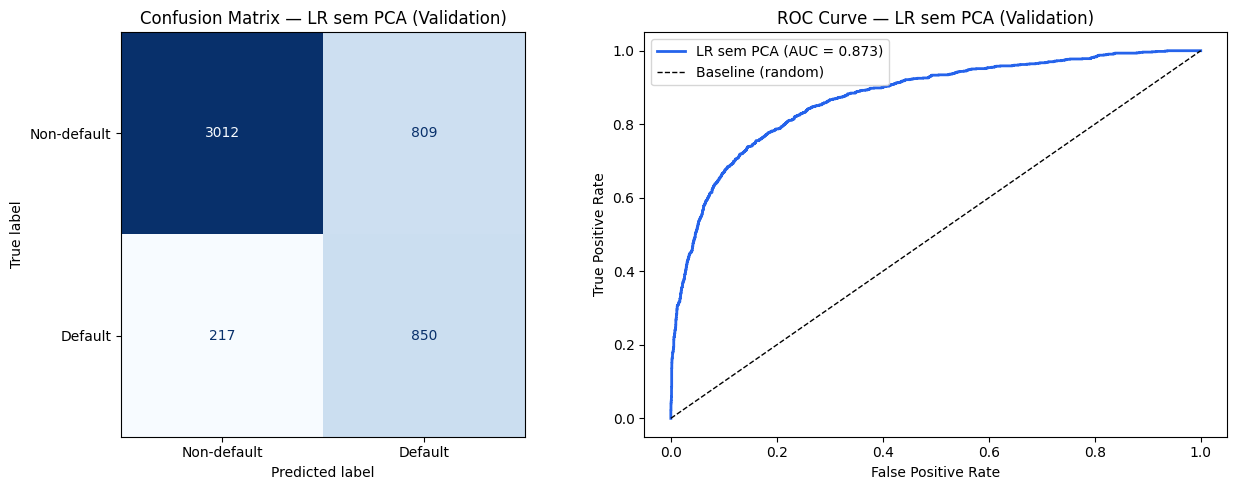

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm = confusion_matrix(y_val, lr.predict(X_val))
ConfusionMatrixDisplay(cm, display_labels=['Non-default', 'Default']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Confusion Matrix — LR sem PCA (Validation)', fontsize=12)

# ROC curve
fpr, tpr, _ = roc_curve(y_val, lr_val_proba)
axes[1].plot(fpr, tpr, color='#2563eb', lw=2,
             label=f'LR sem PCA (AUC = {lr_metrics["ROC-AUC"]:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Baseline (random)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — LR sem PCA (Validation)', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/lr_nopca_val.png', dpi=150, bbox_inches='tight')
plt.show()

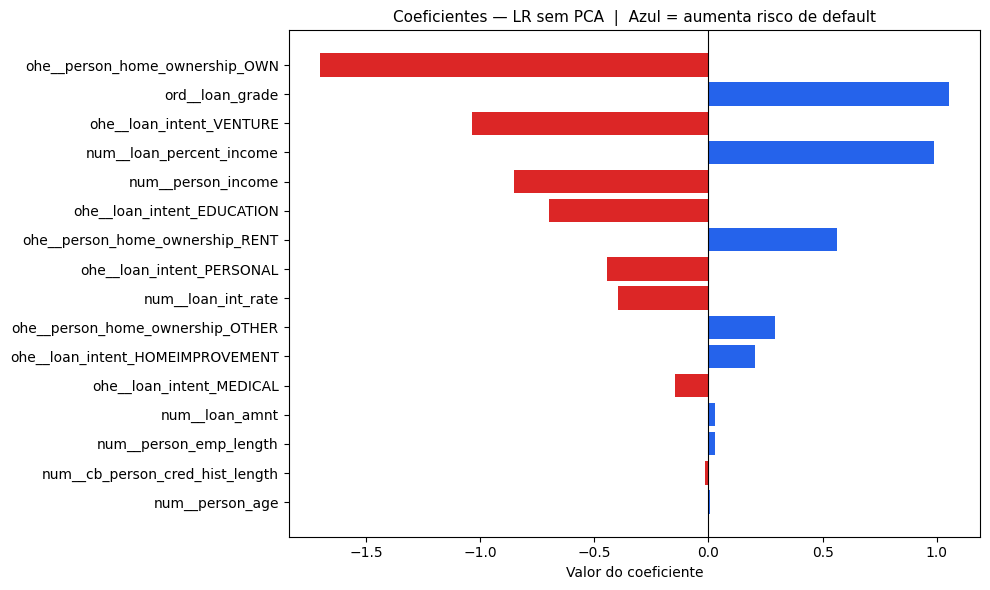

In [64]:
# Coeficientes — importância das features
coef_df = pd.DataFrame({
    'feature':     X_train.columns,
    'coefficient': lr.coef_[0]
}).sort_values('coefficient', key=abs, ascending=True)

plt.figure(figsize=(10, 6))
colors = ['#2563eb' if c > 0 else '#dc2626' for c in coef_df['coefficient']]
plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
plt.axvline(0, color='black', lw=0.8)
plt.title('Coeficientes — LR sem PCA  |  Azul = aumenta risco de default', fontsize=11)
plt.xlabel('Valor do coeficiente')
plt.tight_layout()
plt.savefig('../reports/figures/lr_nopca_coef.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 5. PCA — Análise da estrutura numérica

## 5.1 Seleção de variáveis

PCA aplicado **apenas às colunas numéricas** (prefixo `num__` do ColumnTransformer do notebook 4, já standardizadas por RobustScaler).
As colunas codificadas categoricamente são mantidas intactas — aplicar PCA a variáveis dummy distorce o seu significado.

In [65]:
num_cols = [c for c in X_train.columns if c.startswith('num__')]
cat_cols = [c for c in X_train.columns if not c.startswith('num__')]

print(f'Colunas numéricas para PCA ({len(num_cols)}):')
for c in num_cols:
    print(f'  {c}')
print(f'\nColunas categóricas mantidas ({len(cat_cols)}):')
for c in cat_cols:
    print(f'  {c}')

# Separar blocos em train, val e test
X_train_num = X_train[num_cols].values
X_val_num   = X_val[num_cols].values
X_test_num  = X_test[num_cols].values

X_train_cat = X_train[cat_cols].values
X_val_cat   = X_val[cat_cols].values
X_test_cat  = X_test[cat_cols].values

Colunas numéricas para PCA (7):
  num__person_age
  num__person_income
  num__person_emp_length
  num__loan_amnt
  num__loan_int_rate
  num__cb_person_cred_hist_length
  num__loan_percent_income

Colunas categóricas mantidas (9):
  ord__loan_grade
  ohe__person_home_ownership_OTHER
  ohe__person_home_ownership_OWN
  ohe__person_home_ownership_RENT
  ohe__loan_intent_EDUCATION
  ohe__loan_intent_HOMEIMPROVEMENT
  ohe__loan_intent_MEDICAL
  ohe__loan_intent_PERSONAL
  ohe__loan_intent_VENTURE


## 5.2 Variância explicada

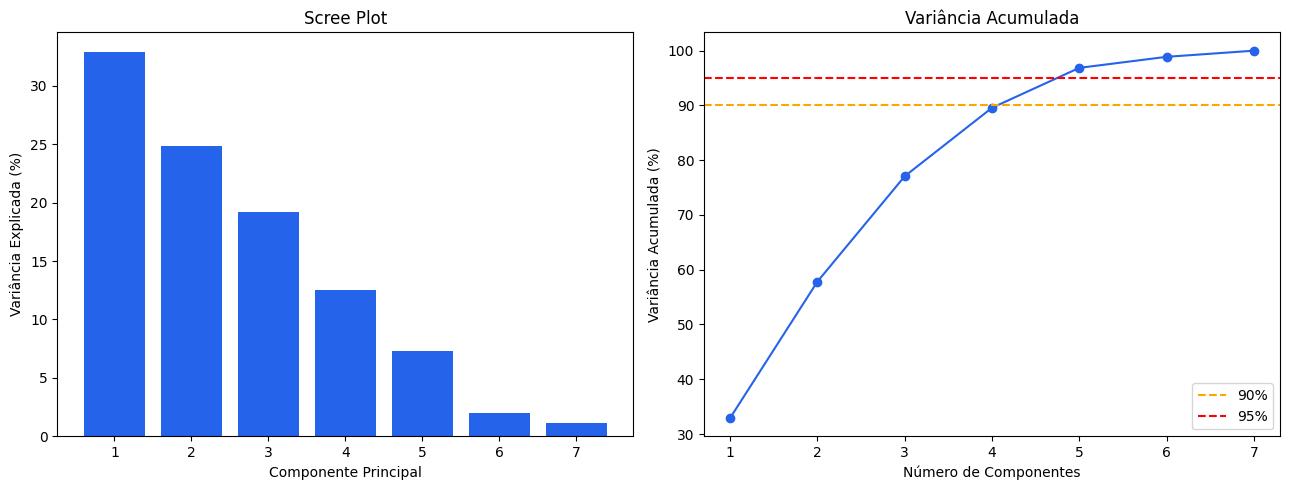

 Componente  Variância Expl (%)  Acumulada (%)
          1             32.9500        32.9500
          2             24.9000        57.8400
          3             19.2400        77.0800
          4             12.4900        89.5700
          5              7.2900        96.8600
          6              2.0200        98.8800
          7              1.1200       100.0000


In [66]:
# PCA ajustado APENAS no treino
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_num)

explained  = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scree plot
axes[0].bar(range(1, len(explained) + 1), explained * 100, color='#2563eb')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Variância Explicada (%)')
axes[0].set_title('Scree Plot')
axes[0].set_xticks(range(1, len(explained) + 1))

# Variância acumulada
axes[1].plot(range(1, len(cumulative) + 1), cumulative * 100,
             marker='o', color='#2563eb')
axes[1].axhline(90, color='orange', linestyle='--', label='90%')
axes[1].axhline(95, color='red',    linestyle='--', label='95%')
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Variância Acumulada (%)')
axes[1].set_title('Variância Acumulada')
axes[1].set_xticks(range(1, len(cumulative) + 1))
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

pca_summary = pd.DataFrame({
    'Componente':        range(1, len(explained) + 1),
    'Variância Expl (%)': (explained * 100).round(2),
    'Acumulada (%)':     (cumulative * 100).round(2)
})
print(pca_summary.to_string(index=False))

## 5.3 Seleção do número de componentes

In [67]:
# Mínimo de componentes que retêm >= 90% da variância
N_COMPONENTS = int(np.argmax(cumulative >= 0.90)) +1
print(f'Componentes para >= 90% de variância: {N_COMPONENTS}')
print(f'Variância retida:                     {cumulative[N_COMPONENTS - 1] * 100:.2f}%')
print(f'Redução de dimensão:                  {len(num_cols)} → {N_COMPONENTS} features numéricas')

# Ajustar PCA final APENAS no treino
pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
pca.fit(X_train_num)

# Transformar os três splits
X_train_pca_num = pca.transform(X_train_num)
X_val_pca_num   = pca.transform(X_val_num)
X_test_pca_num  = pca.transform(X_test_num)

# Concatenar com as features categóricas
X_train_pca = np.hstack([X_train_pca_num, X_train_cat])
X_val_pca   = np.hstack([X_val_pca_num,   X_val_cat])
X_test_pca  = np.hstack([X_test_pca_num,  X_test_cat])

print(f'\nDimensões finais:')
print(f'  Sem PCA  : {X_train.shape[1]} features')
print(f'  Com PCA  : {X_train_pca.shape[1]} features ({N_COMPONENTS} PCs + {len(cat_cols)} categóricas)')

Componentes para >= 90% de variância: 5
Variância retida:                     96.86%
Redução de dimensão:                  7 → 5 features numéricas

Dimensões finais:
  Sem PCA  : 16 features
  Com PCA  : 14 features (5 PCs + 9 categóricas)


## 5.4 Interpretação dos componentes (loadings)

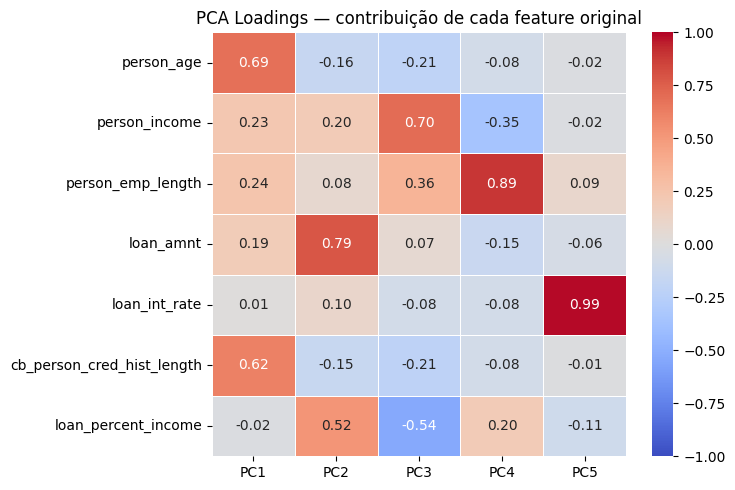

                               PC1     PC2     PC3     PC4     PC5
person_age                  0.6860 -0.1630 -0.2080 -0.0790 -0.0200
person_income               0.2310  0.2020  0.6960 -0.3520 -0.0180
person_emp_length           0.2450  0.0760  0.3590  0.8930  0.0920
loan_amnt                   0.1920  0.7880  0.0680 -0.1480 -0.0580
loan_int_rate               0.0120  0.0960 -0.0830 -0.0790  0.9880
cb_person_cred_hist_length  0.6160 -0.1530 -0.2120 -0.0800 -0.0130
loan_percent_income        -0.0220  0.5230 -0.5360  0.1970 -0.1090


In [68]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=[c.replace('num__', '') for c in num_cols],
    columns=[f'PC{i+1}' for i in range(N_COMPONENTS)]
).round(3)

plt.figure(figsize=(max(7, N_COMPONENTS * 1.5), 5))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title('PCA Loadings — contribuição de cada feature original', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/figures/pca_loadings.png', dpi=150, bbox_inches='tight')
plt.show()

print(loadings)

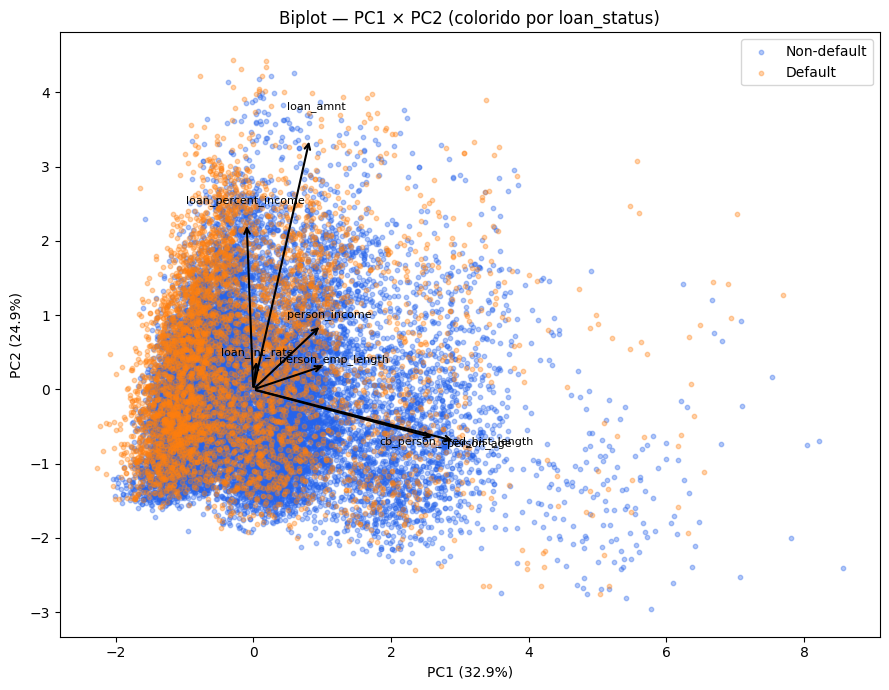

In [69]:
# Biplot PC1 x PC2
fig, ax = plt.subplots(figsize=(9, 7))

for cls, lbl, clr in [(0, 'Non-default', '#2563eb'), (1, 'Default', '#ff7f0e')]:
    mask = y_train.values == cls
    ax.scatter(X_train_pca_num[mask, 0], X_train_pca_num[mask, 1],
               c=clr, label=lbl, alpha=0.35, s=10)

scale = np.abs(X_train_pca_num[:, :2]).max() * 0.5
for i, feat in enumerate(num_cols):
    ax.annotate('',
        xy=(pca.components_[0, i] * scale, pca.components_[1, i] * scale),
        xytext=(0, 0),
        arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
    ax.text(pca.components_[0, i] * scale * 1.12,
            pca.components_[1, i] * scale * 1.12,
            feat.replace('num__', ''), fontsize=8, ha='center')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Biplot — PC1 × PC2 (colorido por loan_status)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/pca_biplot.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 6. Logistic Regression — Com PCA

Mesmo modelo LR treinado sobre os scores PCA (bloco numérico comprimido) + features categóricas originais.
Avaliado na **validação** para comparar com os modelos anteriores.

In [70]:
# Ajustar no treino
lr_pca = LogisticRegression(
    penalty='l2',
    C=1.0,
    class_weight='balanced',
    solver='lbfgs',
    max_iter=1000,
    random_state=RANDOM_STATE
)
lr_pca.fit(X_train_pca, y_train)
print('Logistic Regression (com PCA) treinada.')

Logistic Regression (com PCA) treinada.


In [71]:
# Avaliar na validação
lr_pca_metrics, lr_pca_val_proba = evaluate(
    lr_pca, X_val_pca, y_val,
    label='LR com PCA — Validation set'
)


=== LR com PCA — Validation set ===
  Accuracy               0.7901
  Balanced Accuracy      0.7931
  ROC-AUC                0.8726
  F1 (class 1)           0.6242
  Precision              0.5123
  Recall                 0.7985

              precision    recall  f1-score   support

 Non-default       0.93      0.79      0.85      3821
     Default       0.51      0.80      0.62      1067

    accuracy                           0.79      4888
   macro avg       0.72      0.79      0.74      4888
weighted avg       0.84      0.79      0.80      4888



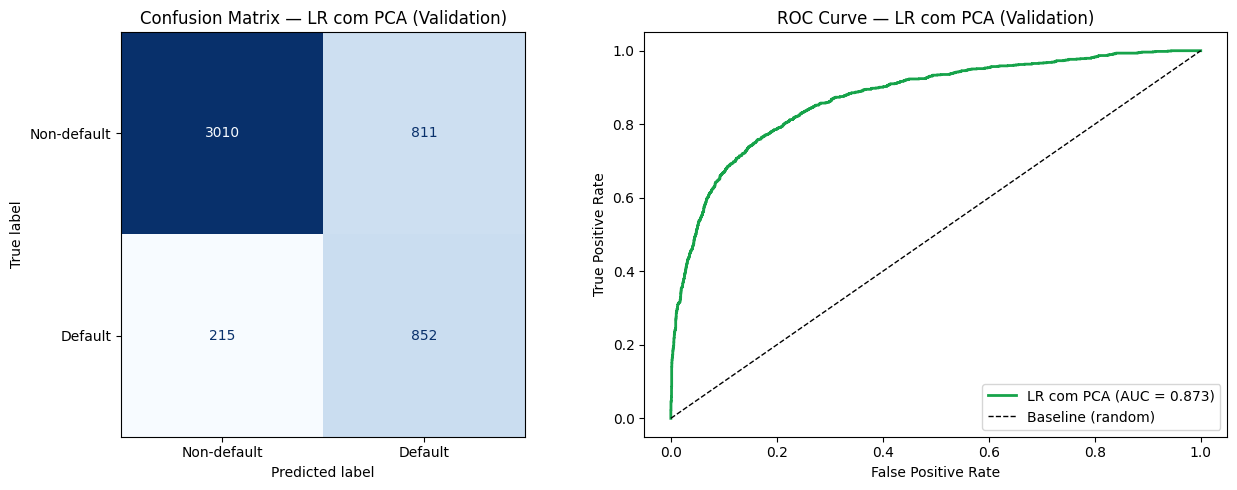

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_pca = confusion_matrix(y_val, lr_pca.predict(X_val_pca))
ConfusionMatrixDisplay(cm_pca, display_labels=['Non-default', 'Default']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Confusion Matrix — LR com PCA (Validation)', fontsize=12)

fpr_pca, tpr_pca, _ = roc_curve(y_val, lr_pca_val_proba)
axes[1].plot(fpr_pca, tpr_pca, color='#16a34a', lw=2,
             label=f'LR com PCA (AUC = {lr_pca_metrics["ROC-AUC"]:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Baseline (random)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — LR com PCA (Validation)', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/lr_pca_val.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 7. Comparação na Validação — Escolha do modelo final

Os três modelos são comparados na validação.
O teste permanece **intocado** até à secção 8.

In [73]:
comparison_val = pd.DataFrame({
    'Métrica':           list(lr_metrics.keys()),
    'Baseline (Dummy)':  list(baseline_metrics.values()),
    'LR sem PCA':        list(lr_metrics.values()),
    'LR com PCA':        list(lr_pca_metrics.values()),
}).set_index('Métrica')

comparison_val['Δ PCA vs sem PCA'] = (
    comparison_val['LR com PCA'] - comparison_val['LR sem PCA']
).round(4)

print('=' * 70)
print('COMPARAÇÃO NA VALIDAÇÃO')
print('=' * 70)
display(comparison_val)

COMPARAÇÃO NA VALIDAÇÃO


,Baseline (Dummy),LR sem PCA,LR com PCA,Δ PCA vs sem PCA
Métrica,,,,
Accuracy,0.7817,0.7901,0.7901,0.0000
Balanced Accuracy,0.5000,0.7925,0.7931,0.0007
ROC-AUC,NaN,0.8725,0.8726,0.0000
F1 (class 1),0.0000,0.6236,0.6242,0.0006
Precision,0.0000,0.5124,0.5123,-0.0000
Recall,0.0000,0.7966,0.7985,0.0019


### Seleção do modelo e justificação:


Optamos por seguir com o modelo 'LR sem PCA'. A redução de dimensionalidade 
via PCA não trouxe ganhos de performance que justificassem a perda de 
interpretabilidade das variáveis. No contexto de risco de crédito, manter o 
modelo open-box (sem a caixa-preta do PCA) permite explicar diretamente o 
impacto de features como rendimento e montante do empréstimo na decisão final.

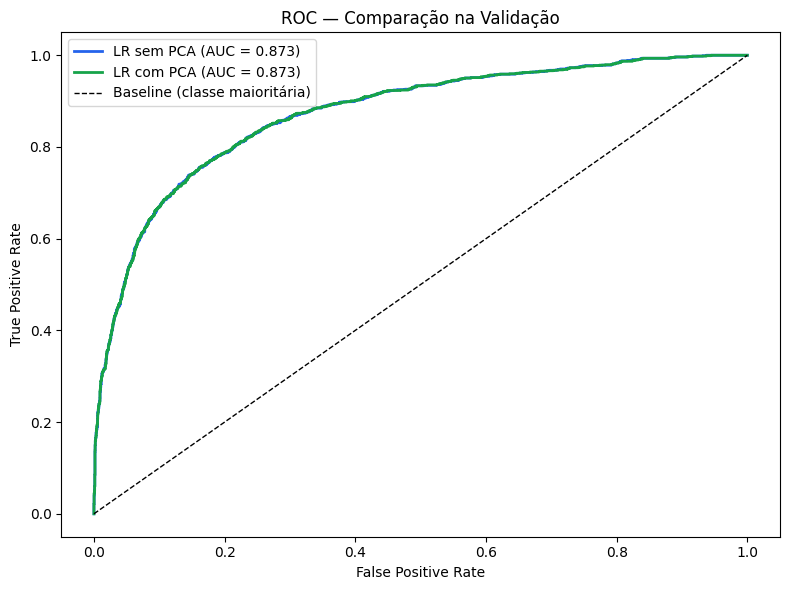

In [74]:
# Curvas ROC sobrepostas (validação)
plt.figure(figsize=(8, 6))

for label, proba, clr in [
    ('LR sem PCA', lr_val_proba,     '#2563eb'),
    ('LR com PCA', lr_pca_val_proba, '#16a34a'),
]:
    fpr_, tpr_, _ = roc_curve(y_val, proba)
    auc_ = roc_auc_score(y_val, proba)
    plt.plot(fpr_, tpr_, lw=2, color=clr, label=f'{label} (AUC = {auc_:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Baseline (classe maioritária)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC — Comparação na Validação')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/roc_comparison_val.png', dpi=150, bbox_inches='tight')
plt.show()

In [75]:

best_model_name = 'LR sem PCA'
best_model      = lr
X_test_final    = X_test

print(f"=== Decisão de Modelagem ===")
print(f"Modelo selecionado: {best_model_name}")
print(f"Balanced Accuracy na validação: {lr_metrics['Balanced Accuracy']:.4f}")
print("\nModelo configurado para a avaliação final e análise de erro com variáveis originais.")

=== Decisão de Modelagem ===
Modelo selecionado: LR sem PCA
Balanced Accuracy na validação: 0.7925

Modelo configurado para a avaliação final e análise de erro com variáveis originais.


---
# 8. Avaliação Final no Teste

> *"Test: avaliação final — uso único no fim — estimativa honesta de generalização"* (slides da aula)

O teste é usado **uma única vez**, com o modelo escolhido na secção anterior.

In [76]:
print(f'Avaliando "{best_model_name}" no TEST SET (uso único)')
print('=' * 55)

final_metrics, final_proba = evaluate(
    best_model, X_test_final, y_test,
    label=f'{best_model_name} — TEST SET (resultado final)'
)

Avaliando "LR sem PCA" no TEST SET (uso único)

=== LR sem PCA — TEST SET (resultado final) ===
  Accuracy               0.7905
  Balanced Accuracy      0.7916
  ROC-AUC                0.8726
  F1 (class 1)           0.6230
  Precision              0.5127
  Recall                 0.7936

              precision    recall  f1-score   support

 Non-default       0.93      0.79      0.85      3821
     Default       0.51      0.79      0.62      1066

    accuracy                           0.79      4887
   macro avg       0.72      0.79      0.74      4887
weighted avg       0.84      0.79      0.80      4887



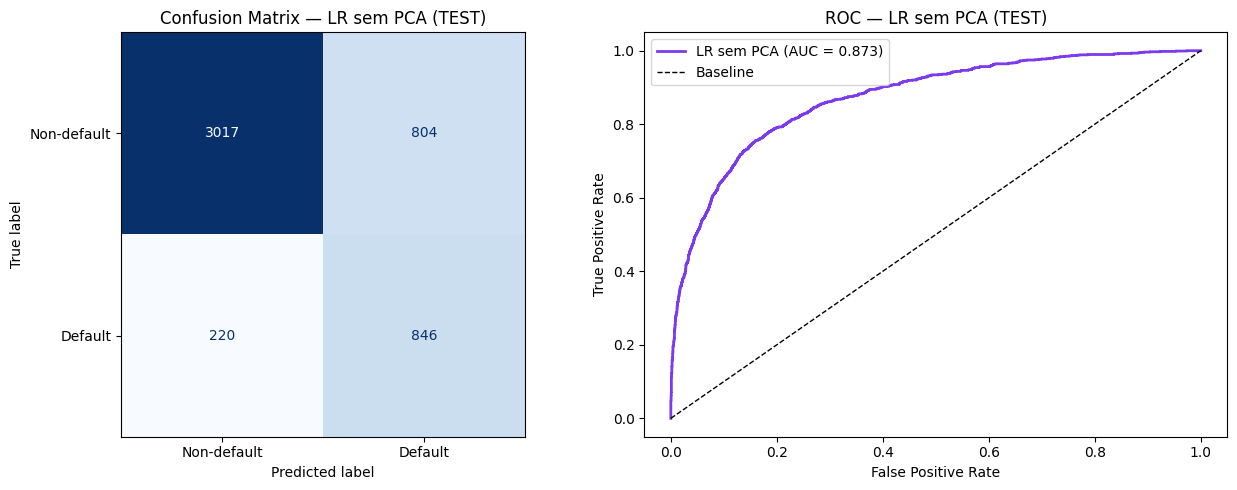

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix — teste
cm_final = confusion_matrix(y_test, best_model.predict(X_test_final))
ConfusionMatrixDisplay(cm_final, display_labels=['Non-default', 'Default']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title(f'Confusion Matrix — {best_model_name} (TEST)', fontsize=12)

# ROC curve — teste
fpr_f, tpr_f, _ = roc_curve(y_test, final_proba)
axes[1].plot(fpr_f, tpr_f, color='#7c3aed', lw=2,
             label=f'{best_model_name} (AUC = {final_metrics["ROC-AUC"]:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'ROC — {best_model_name} (TEST)', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/final_test_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [78]:
joblib.dump(lr,     '../data/processed/model_lr_nopca.pkl')
joblib.dump(lr_pca, '../data/processed/model_lr_pca.pkl')
joblib.dump(pca,    '../data/processed/pca_transformer.pkl')
print('Modelos guardados em ../data/processed/')

Modelos guardados em ../data/processed/


---
# 9. Error Analysis & Limitações

Análise de erros realizada sobre o **modelo final** no conjunto de teste.

In [79]:
y_pred_final = best_model.predict(X_test_final)

error_df = pd.DataFrame(X_test_final if isinstance(X_test_final, np.ndarray)
                        else X_test_final.values)
error_df.columns = (X_test.columns if best_model_name == 'LR sem PCA'
                    else [f'f{i}' for i in range(X_test_final.shape[1])])
error_df['y_true']  = y_test.values
error_df['y_pred']  = y_pred_final
error_df['y_proba'] = final_proba

error_df['error_type'] = 'Correct'
error_df.loc[(error_df['y_true']==1) & (error_df['y_pred']==0), 'error_type'] = 'False Negative'
error_df.loc[(error_df['y_true']==0) & (error_df['y_pred']==1), 'error_type'] = 'False Positive'

print(error_df['error_type'].value_counts())

error_type
Correct           3863
False Positive     804
False Negative     220
Name: count, dtype: int64


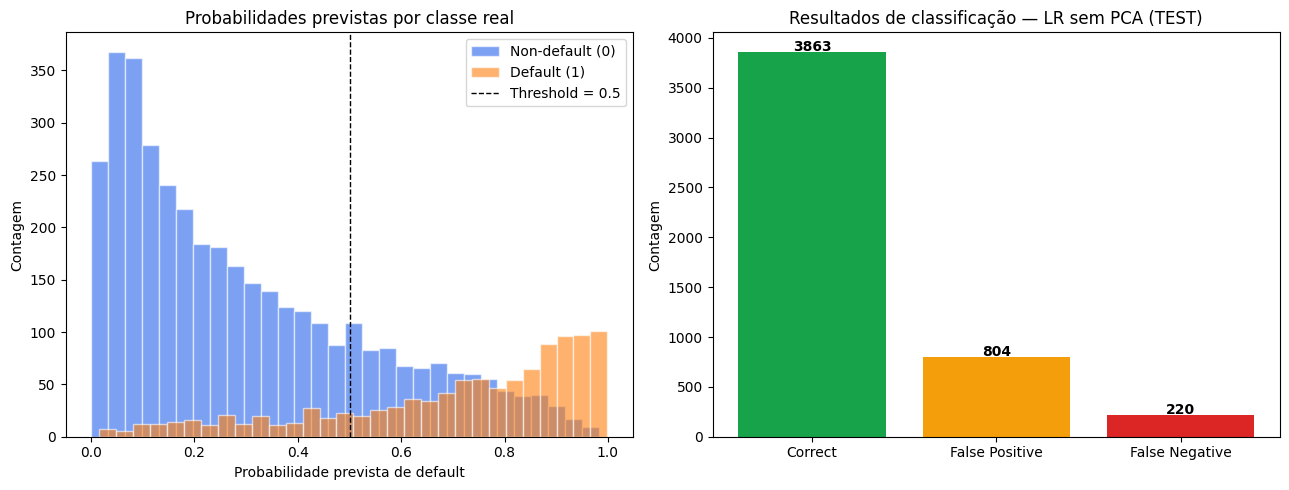

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribuição de probabilidades por classe real
for cls, lbl, clr in [(0,'Non-default (0)','#2563eb'),(1,'Default (1)','#ff7f0e')]:
    subset = error_df[error_df['y_true']==cls]['y_proba']
    axes[0].hist(subset, bins=30, alpha=0.6, label=lbl, color=clr, edgecolor='white')
axes[0].axvline(0.5, color='black', linestyle='--', lw=1, label='Threshold = 0.5')
axes[0].set_xlabel('Probabilidade prevista de default')
axes[0].set_ylabel('Contagem')
axes[0].set_title('Probabilidades previstas por classe real')
axes[0].legend()

# Contagem por tipo de erro
error_counts = error_df['error_type'].value_counts()
bar_colors = {'Correct':'#16a34a','False Negative':'#dc2626','False Positive':'#f59e0b'}
axes[1].bar(error_counts.index, error_counts.values,
            color=[bar_colors.get(k,'grey') for k in error_counts.index])
axes[1].set_title(f'Resultados de classificação — {best_model_name} (TEST)')
axes[1].set_ylabel('Contagem')
for i, (idx, val) in enumerate(error_counts.items()):
    axes[1].text(i, val+5, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

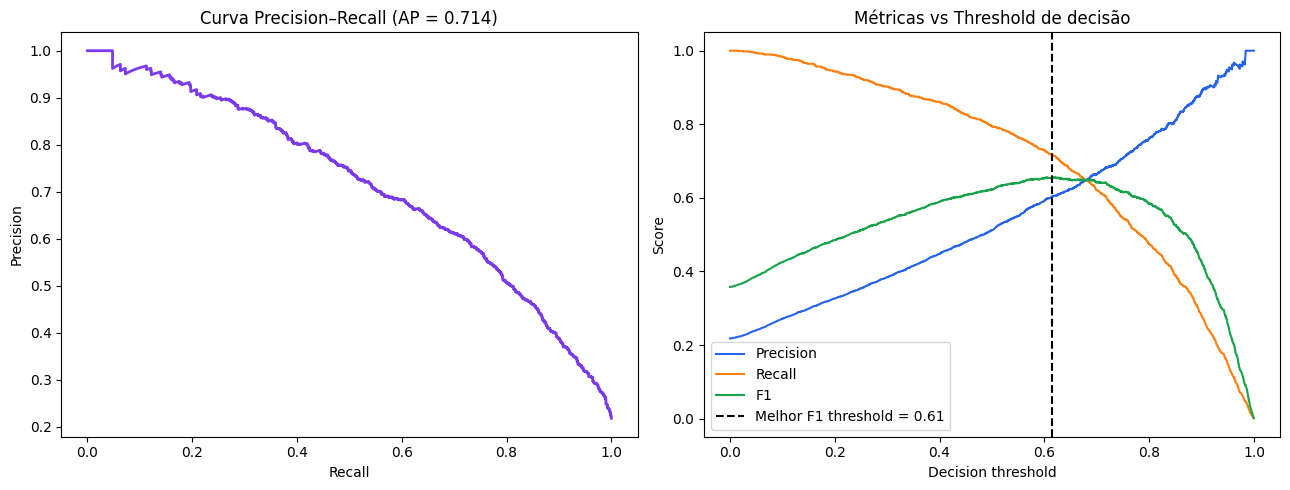

Threshold padrão (0.50): F1 = 0.6227
Melhor threshold (0.61):  F1 = 0.6564


In [81]:
# Trade-off Precision-Recall e threshold ótimo de F1
prec, rec, thresholds = precision_recall_curve(y_test, final_proba)
ap = average_precision_score(y_test, final_proba)
f1_by_thr = 2*(prec[:-1]*rec[:-1])/(prec[:-1]+rec[:-1]+1e-9)
best_idx  = np.argmax(f1_by_thr)
best_thr  = thresholds[best_idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(rec, prec, color='#7c3aed', lw=2)
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title(f'Curva Precision–Recall (AP = {ap:.3f})')

axes[1].plot(thresholds, prec[:-1], label='Precision', color='#2563eb')
axes[1].plot(thresholds, rec[:-1],  label='Recall',    color='#ff7f0e')
axes[1].plot(thresholds, f1_by_thr, label='F1',        color='#16a34a')
axes[1].axvline(best_thr, color='black', linestyle='--',
                label=f'Melhor F1 threshold = {best_thr:.2f}')
axes[1].set_xlabel('Decision threshold'); axes[1].set_ylabel('Score')
axes[1].set_title('Métricas vs Threshold de decisão')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/precision_recall_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Threshold padrão (0.50): F1 = {f1_by_thr[np.argmin(abs(thresholds-0.5))]:.4f}')
print(f'Melhor threshold ({best_thr:.2f}):  F1 = {f1_by_thr[best_idx]:.4f}')

## 9.1 Limitações e pressupostos do modelo

| Limitação | Impacto | Mitigação sugerida |
|-----------|---------|-------------------|
| **Desbalanceamento (~78/22)** | Accuracy enganosa; o modelo pode sub-detetar defaults | `class_weight='balanced'` aplicado; threshold tuning possível |
| **Fronteira de decisão linear** | Não captura interações não-lineares (ex: idade × renda) | Gradient Boosting como próximo passo |
| **Outliers parcialmente removidos** | Rendas e idades extremas podem distorcer coeficientes | Winsorização ao percentil 99 |
| **Dados imputados por mediana** | `loan_int_rate` (9.6% missing, provável MNAR) pode introduzir viés | Imputação múltipla ou variável indicadora |
| **`loan_grade` potencialmente leaky** | Atribuída pós-avaliação; pode codificar parcialmente o target | Análise de sensibilidade sem `loan_grade` |
| **PCA reduz interpretabilidade** | Componentes principais sem significado direto de negócio | Manter LR sem PCA como modelo primário |
| **Sem split temporal** | Split aleatório pode misturar padrões temporais | Split cronológico se timestamps disponíveis |

---
# 10. Reproducibilidade

In [82]:
import platform, sklearn, scipy, matplotlib, seaborn

print('=== Reproducibility Statement ===')
print(f'Python        : {platform.python_version()}')
print(f'pandas        : {pd.__version__}')
print(f'numpy         : {np.__version__}')
print(f'scikit-learn  : {sklearn.__version__}')
print(f'scipy         : {scipy.__version__}')
print(f'matplotlib    : {matplotlib.__version__}')
print(f'seaborn       : {seaborn.__version__}')
print(f'joblib        : {joblib.__version__}')
print()
print(f'Random seed global: RANDOM_STATE = {RANDOM_STATE}')
print()
print('Para reproduzir desde o início:')
print('  pip install -r requirements.txt')
print('  Executar notebooks por ordem: 0 → 1 → 2 → 3 → 4 → 5')

=== Reproducibility Statement ===
Python        : 3.14.3
pandas        : 3.0.1
numpy         : 2.4.2
scikit-learn  : 1.9.0
scipy         : 1.17.1
matplotlib    : 3.10.9
seaborn       : 0.13.2
joblib        : 1.5.3

Random seed global: RANDOM_STATE = 42

Para reproduzir desde o início:
  pip install -r requirements.txt
  Executar notebooks por ordem: 0 → 1 → 2 → 3 → 4 → 5
